<a href="https://colab.research.google.com/github/alohe-lang/titanic-prediction/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import plotly as plt
import seaborn as sns

train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
train.info()
test.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [14]:
print(set(train.columns)-set(test.columns))

{'Survived'}


In [15]:
survival_male = train[train['Sex'] == 'male']['Survived'].mean()
survival_female = train[train['Sex'] == 'female']['Survived'].mean()

print(survival_male)
print(survival_female)

0.18890814558058924
0.7420382165605095


AttributeError: module 'plotly' has no attribute 'title'

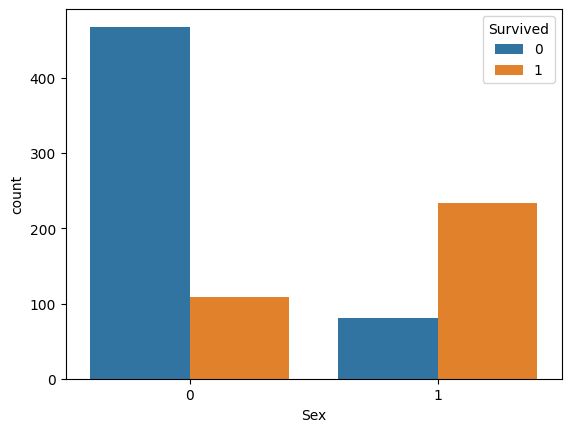

In [28]:
sns.countplot(data=train, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.show()

In [26]:
median_age = train['Age'].median()

train['Age'] = train['Age'].fillna(median_age)
test['Age'] = test['Age'].fillna(median_age)

print(train['Age'].isna().sum())
print(test['Age'].isna().sum())



0
0


In [17]:
median_Fare = train['Fare'].median()

train['Fare'] = train['Fare'].fillna(median_Fare)
test['Fare'] = test['Fare'].fillna(median_Fare)

print(train['Fare'].isna().sum())
print(test['Fare'].isna().sum())

0
0


In [18]:
sex_binary = {'male':0, 'female' : 1}

In [19]:
train['Sex'] = train['Sex'].map(sex_binary)
test['Sex'] = test['Sex'].map(sex_binary)

print(train['Sex'].isna().sum())
print(test['Sex'].isna().sum())
train.head()


0
0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [29]:
X = train[['Pclass', 'Sex','Fare','Age','SibSp','Parch']]
y = train['Survived']
print(X.isna().sum())

Pclass    0
Sex       0
Fare      0
Age       0
SibSp     0
Parch     0
dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_val,y_train,y_val = train_test_split(X, y, test_size=0.2,random_state= 42)
print(X_train.shape,X_val.shape)

(712, 6) (179, 6)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter =1000)
model.fit(X_train,y_train)

predictions = model.predict(X_val)
print(accuracy_score(y_val,predictions))

0.8100558659217877


In [32]:
X_test = test[['Pclass', 'Sex','Fare','Age','SibSp','Parch']]
print(X_test.isna().sum())


Pclass    0
Sex       0
Fare      0
Age       0
SibSp     0
Parch     0
dtype: int64


In [37]:
test_pred = model.predict(X_test)
print(test_pred)


[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1 0
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


In [39]:
submit = test[['PassengerId']].copy()
submit['Survived'] = test_pred
submit.to_csv('submit.csv',index=False)
print(submit.shape)

(418, 2)
